# 08 – Model Calibration and Probability Scaling

**Purpose:** Calibrate our fine-tuned `DistilBERT` sequence classifier probabilities using Temperature Scaling, and evaluate ECE/Brier scores.

This notebook demonstrates:
1. Loading validation and test logits.
2. Optimising the Temperature parameter $T$ on validation logits.
3. Applying scaling and comparing uncalibrated vs. calibrated probabilities.
4. Calculating Expected Calibration Error (ECE) and Brier scores.
5. Displaying Reliability Diagrams, Confidence Histograms, and Threshold routing curves.

## 0. Setup and Environment

In [1]:
import sys
from pathlib import Path
import pandas as pd
import IPython.display as display

REPO_ROOT = Path().resolve().parent
if REPO_ROOT.name != "SupportAI" and (REPO_ROOT / "SupportAI").exists():
    REPO_ROOT = REPO_ROOT / "SupportAI"
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

print(f"Repo root: {REPO_ROOT}")

Repo root: C:\Users\gunav\Downloads\SupportAI


## 1. Execute Calibration Pipeline

We run the calibration runner to calculate the optimized temperature and export metrics.

In [2]:
from src.evaluation.calibration import CalibrationRunner
from src.utils.constants import OUTPUT_DIR

model_dir = OUTPUT_DIR / "models" / "best_model"

runner = CalibrationRunner(model_dir, smoke_run=False)
metrics = runner.calibrate()

print("Calibration complete!")
print(f"Optimised Temperature: {metrics['optimized_temperature']:.4f}")
print(f"ECE (Before): {metrics['ece_before']:.4f} | ECE (After): {metrics['ece_after']:.4f}")
print(f"Brier (Before): {metrics['brier_before']:.4f} | Brier (After): {metrics['brier_after']:.4f}")

[07/13/26 16:40:20] INFO     Loading faiss with AVX2 support.

                    INFO     Could not load library with AVX2 support due to:                                      
                             ModuleNotFoundError("No module named 'faiss.swigfaiss_avx2'")

                    INFO     Loading faiss.

                    INFO     Successfully loaded faiss.

                    INFO     Loading model for calibration from:                                                   
                             C:\Users\gunav\Downloads\SupportAI\outputs\models\best_model

...

                    INFO     Saving JSON artifact to:                                                              
                             C:\Users\gunav\Downloads\SupportAI\outputs\metrics\calibration_summary.json

                    INFO     Saving visualization figure to:                                                       
                             C:\Users\gunav\Downloads\SupportAI\outputs\metrics\plots\reliability_diagram.png

                    INFO     Saving visualization figure to:                                                       
                             C:\Users\gunav\Downloads\SupportAI\outputs\metrics\plots\confidence_histogram.png

                    INFO     Saving visualization figure to:                                                       
                             C:\Users\gunav\Downloads\SupportAI\outputs\metrics\plots\threshold_study.png

Calibration complete!
Optimised Temperature: 1.1939
ECE (Before): 0.0196 | ECE (After): 0.0393
Brier (Before): 0.1178 | Brier (After): 0.1170


## 2. Display Reliability Diagrams and Histograms

Let's display the before and after diagnostic plots.

Reliability Diagram (Confidence vs Accuracy Bins):


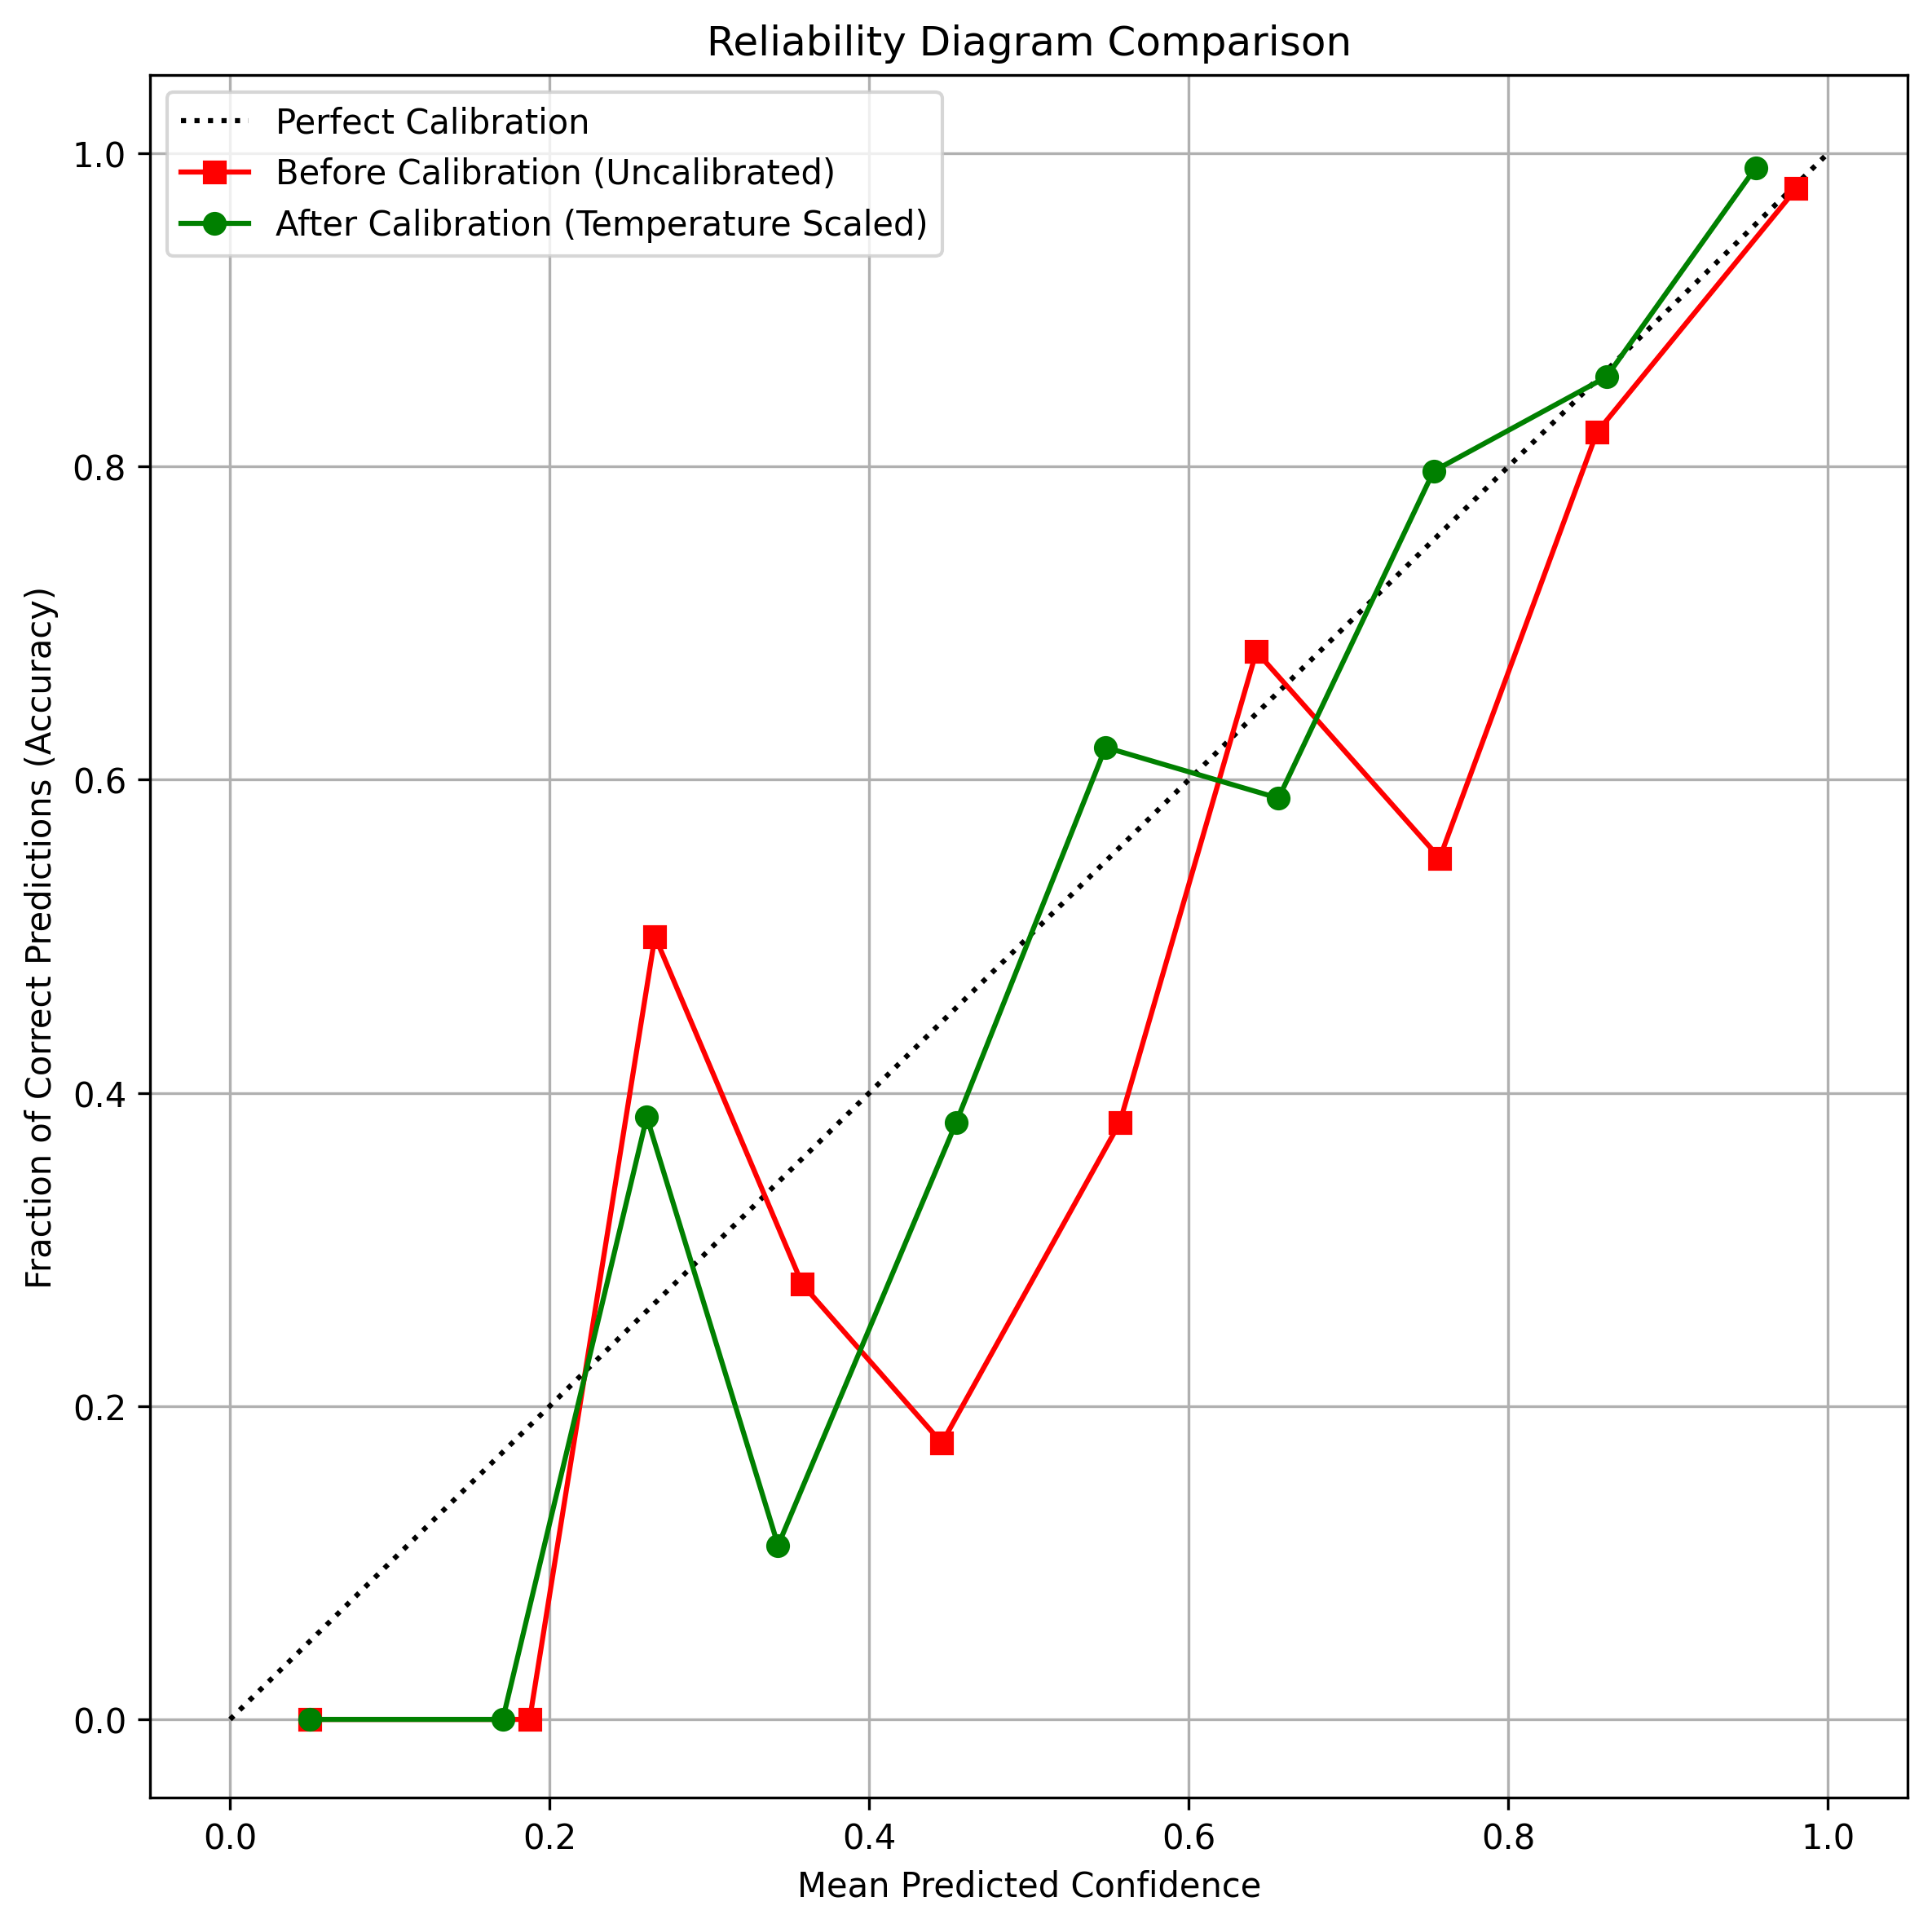


Prediction Confidences Distribution Density:


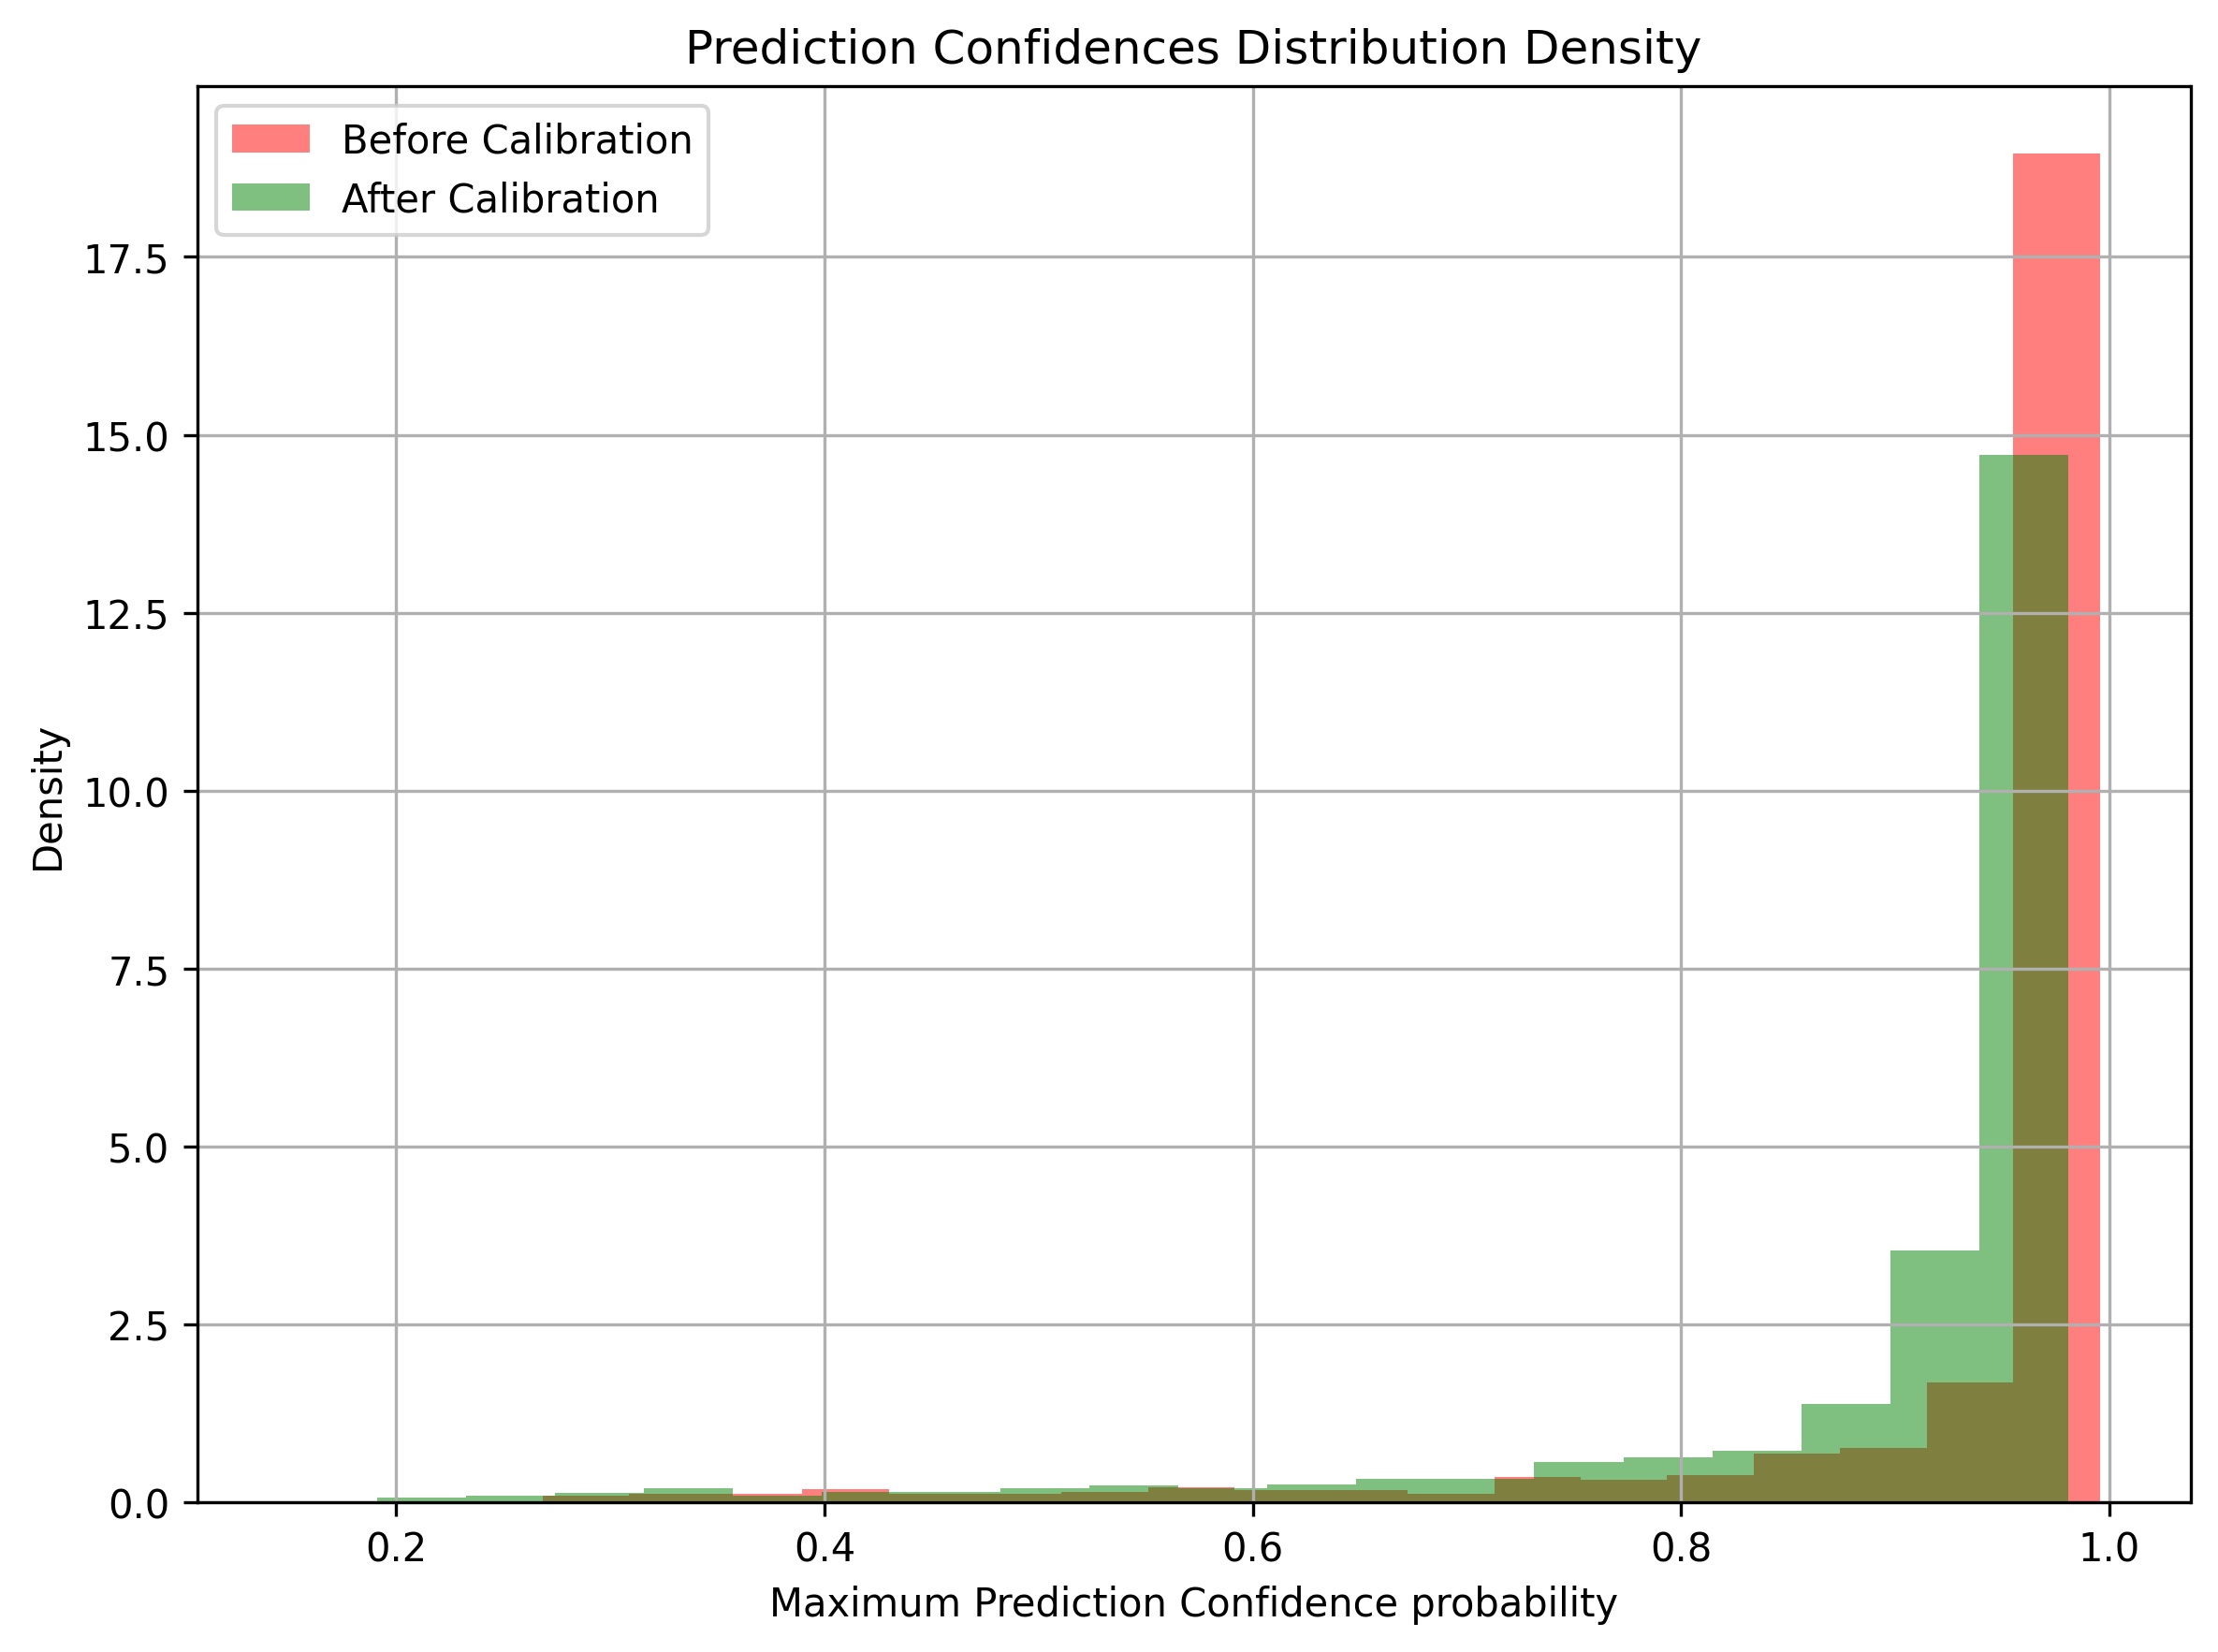


Threshold Routing Study:


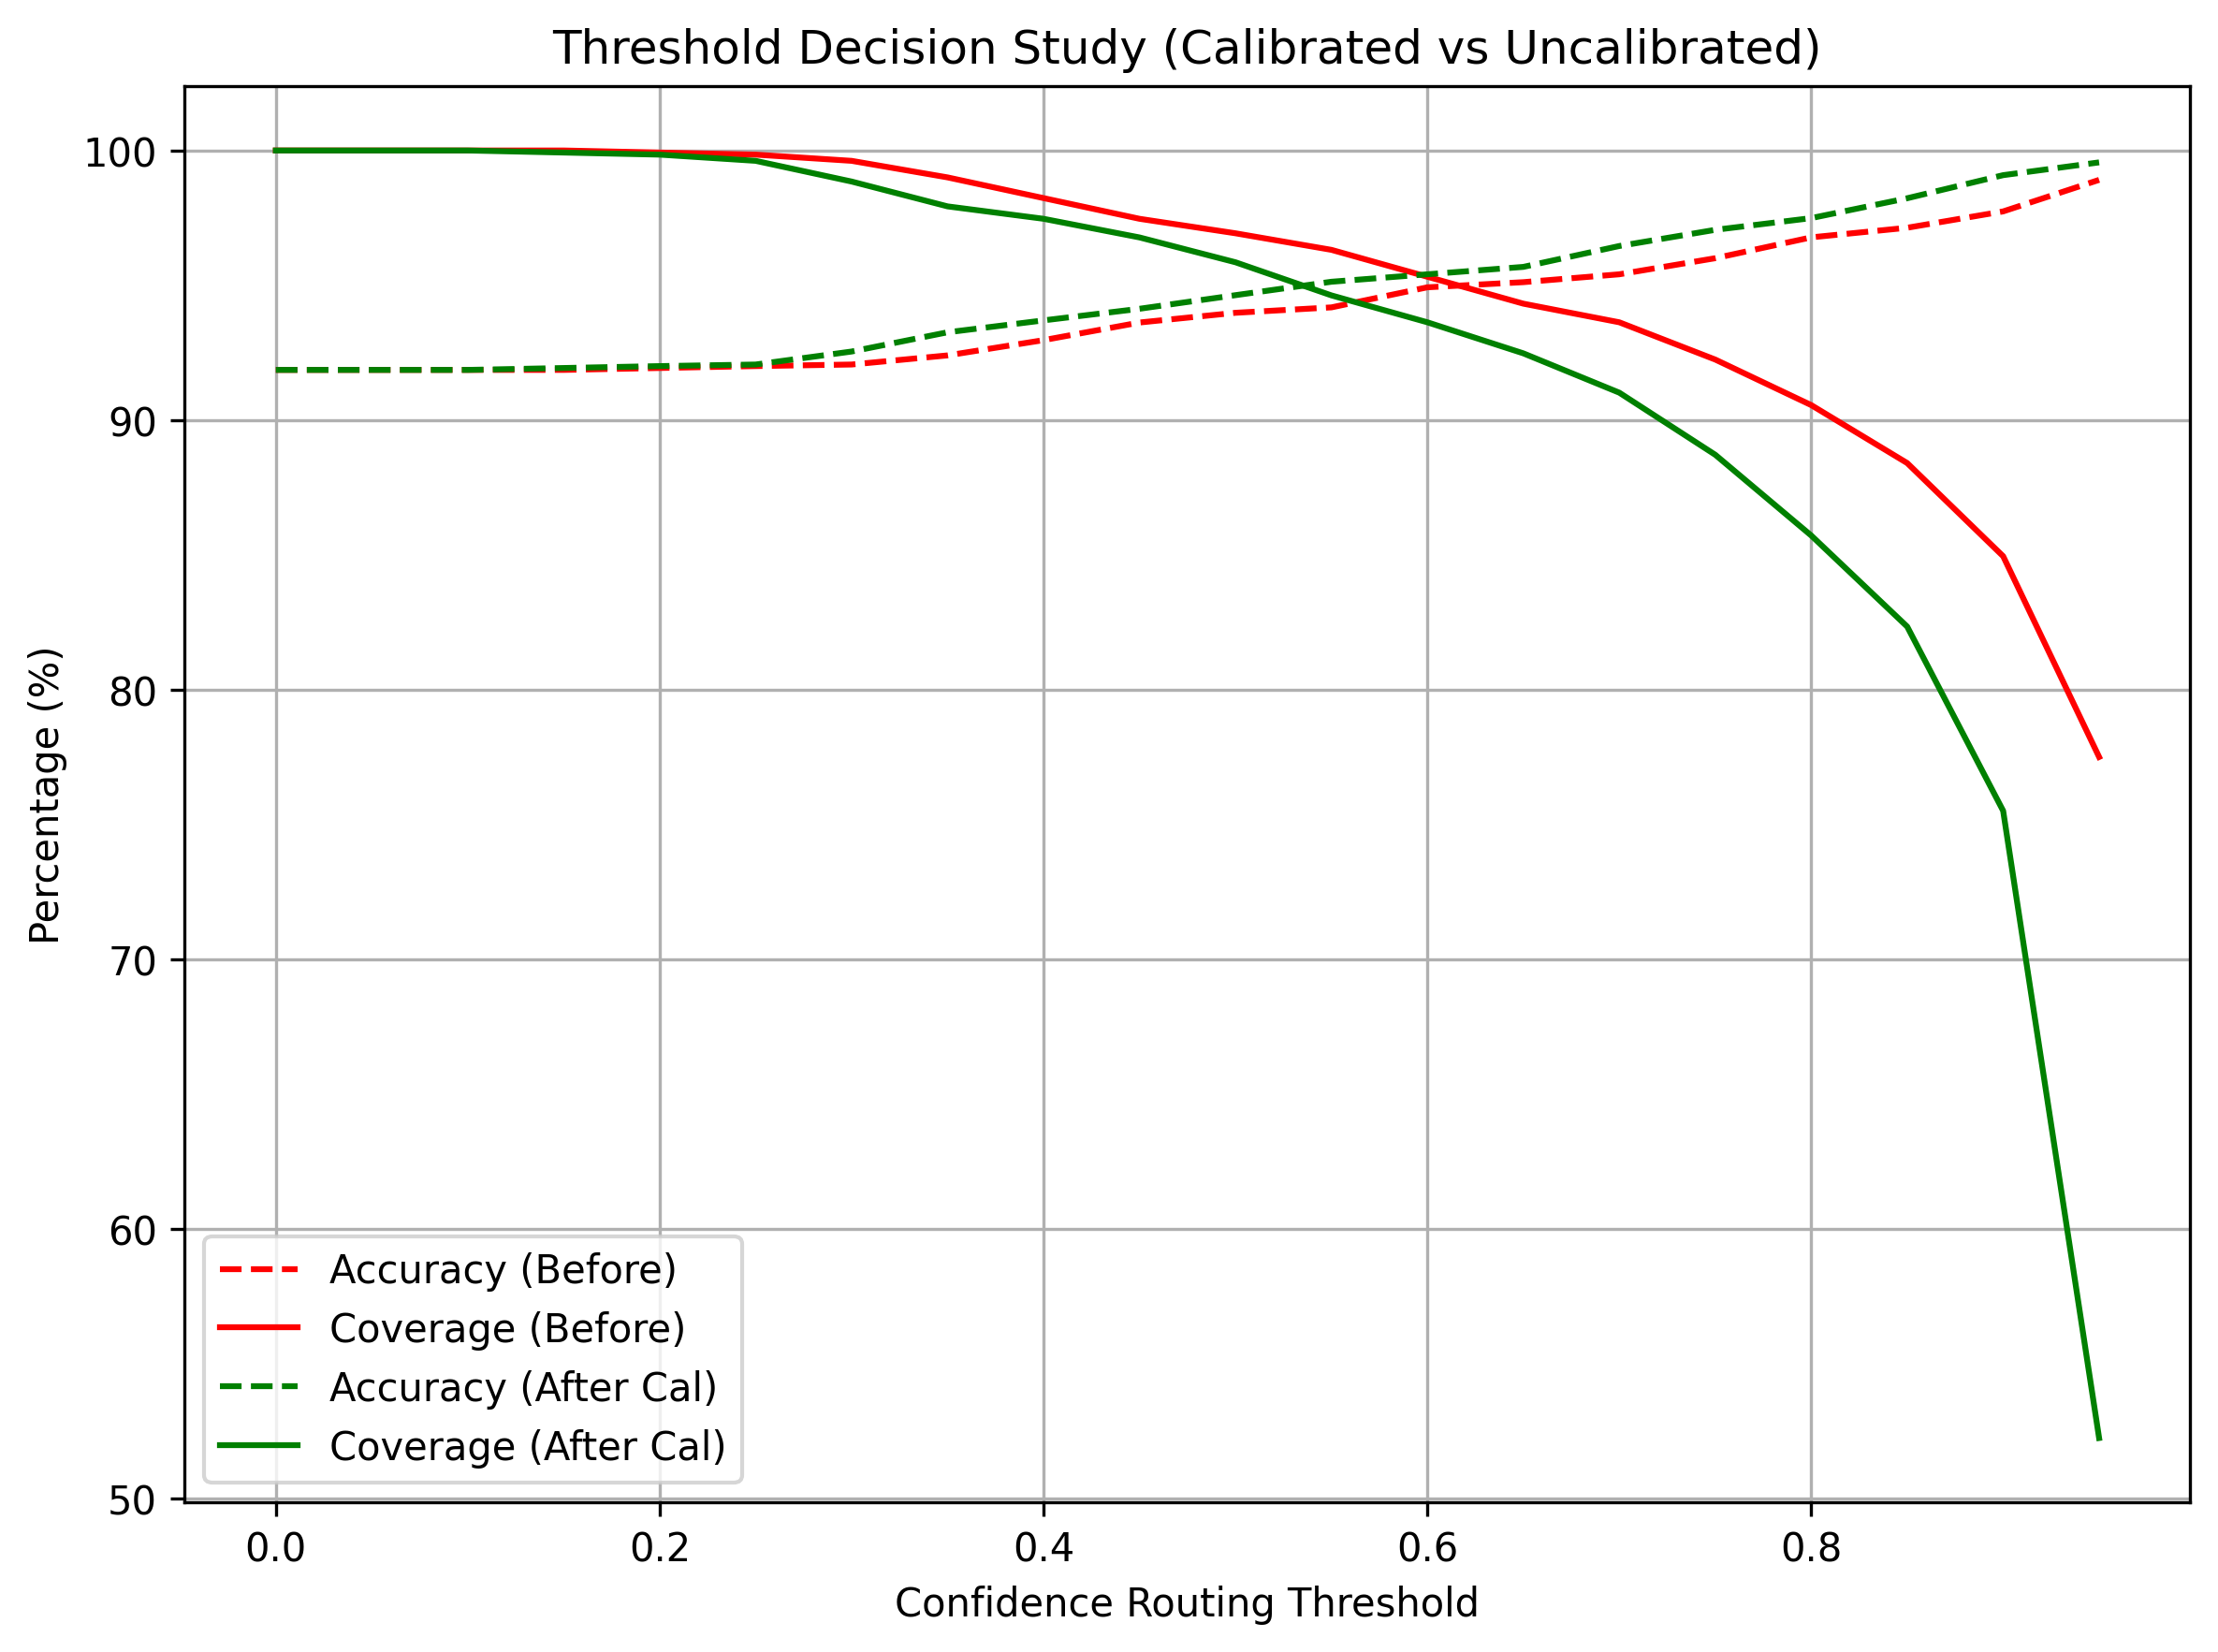

In [3]:
plots_dir = OUTPUT_DIR / "metrics" / "plots"

print("Reliability Diagram (Confidence vs Accuracy Bins):")
display.display(display.Image(filename=str(plots_dir / "reliability_diagram.png")))

print("\nPrediction Confidences Distribution Density:")
display.display(display.Image(filename=str(plots_dir / "confidence_histogram.png")))

print("\nThreshold Routing Study:")
display.display(display.Image(filename=str(plots_dir / "threshold_study.png")))

In [4]:
# Export Phase Manifest
import json
from src.utils.artifacts import save_yaml
from src.api.app import get_git_commit

calibration_metrics_path = REPO_ROOT / "outputs" / "metrics" / "calibration_metrics.json"
calibration_metrics = {}
if calibration_metrics_path.exists():
    with open(calibration_metrics_path) as f:
        calibration_metrics = json.load(f)

manifest = {
    "phase": "08_Calibration",
    "calibration_metrics": calibration_metrics,
    "git_commit": get_git_commit(),
}
save_yaml(manifest, REPO_ROOT / "outputs" / "manifests" / "phase_08_calibration.yaml")
print("YAML manifest saved successfully:")
print(manifest)


[07/13/26 16:40:25] INFO     Saving YAML artifact to:                                                              
                             C:\Users\gunav\Downloads\SupportAI\outputs\manifests\phase_08_calibration.yaml

YAML manifest saved successfully:
{'phase': '08_Calibration', 'calibration_metrics': {'optimized_temperature': 1.19392728805542, 'ece_before': 0.019559950532124837, 'ece_after': 0.039261148272571475, 'brier_before': 0.1178313070901938, 'brier_after': 0.11702445184080554}, 'git_commit': '37354aeb6f944f9626d6869d75347783182ba82b'}
